# Homework 5 - Exercise 2

Extracted from `HW5_completed.ipynb`. This notebook contains only Exercise 2 plus the shared helper cell needed to run it independently.

In [1]:
from pathlib import Path

import autograd.numpy as anp
import matplotlib.pyplot as plt
import numpy as np
from autograd import grad

ROOT = Path(".").resolve()
GLOBAL_SEED = 3


def unpack_exercise_2_params(flat_w):
    feature_params = anp.reshape(flat_w[:6], (3, 2))
    linear_params = anp.reshape(flat_w[6:], (3, 2))
    return feature_params, linear_params


def exercise_2_model(x, flat_w):
    feature_params, linear_params = unpack_exercise_2_params(flat_w)
    transformed = anp.sin(feature_params[0] + anp.dot(x.T, feature_params[1:])).T
    return (linear_params[0] + anp.dot(transformed.T, linear_params[1:])).T


def exercise_2_cost(flat_w, x, y):
    residual = exercise_2_model(x, flat_w) - y
    return 0.5 * anp.mean(residual ** 2)


def gradient_descent(cost_function, init_w, alpha, max_its, x, y):
    w = anp.array(init_w)
    gradient = grad(cost_function)
    cost_history = []
    for _ in range(max_its):
        cost_history.append(float(cost_function(w, x, y)))
        w = w - alpha * gradient(w, x, y)
    cost_history.append(float(cost_function(w, x, y)))
    return np.array(w, dtype=float), cost_history


## Exercise 2


Initial cost: 1.3349391436004772
Final cost: 0.03853587871623123
Feature parameters:
[[ 6.3728 -3.5684]
 [-4.2981  2.8932]
 [-7.4979  1.707 ]]
Linear parameters:
[[-0.1521 -0.63  ]
 [-1.0066  0.5629]
 [-0.2575 -0.9997]]


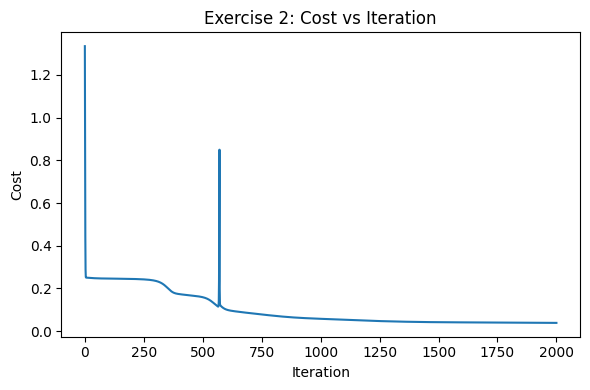

In [2]:
# The CSV stores two input coordinates in the first two rows and two output rows
# in the last two rows.
data = np.loadtxt(ROOT / "multiple_sine_waves.csv", delimiter=",")
x = data[:2, :]
y = data[2:, :]

rng = np.random.default_rng(GLOBAL_SEED)
best_w = None
best_history = None
best_cost = float("inf")

# Because the objective is non-convex, different initializations can converge to
# different local minima. I therefore keep the best run across 50 restarts.
for _ in range(50):
    init = rng.normal(scale=0.5, size=12)
    w_candidate, history = gradient_descent(exercise_2_cost, init, alpha=1.0, max_its=2000, x=x, y=y)
    if history[-1] < best_cost:
        best_cost = history[-1]
        best_w = w_candidate
        best_history = history

# Convert the best flat parameter vector back into its feature-layer and output-layer
# interpretations so the parameters can be reported clearly.
feature_params, linear_params = unpack_exercise_2_params(best_w)
print("Initial cost:", best_history[0])
print("Final cost:", best_history[-1])
print("Feature parameters:")
print(np.round(np.array(feature_params, dtype=float), 4))
print("Linear parameters:")
print(np.round(np.array(linear_params, dtype=float), 4))

# Plot the cost curve to show gradient descent converging.
plt.figure(figsize=(6, 4))
plt.plot(best_history)
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Exercise 2: Cost vs Iteration")
plt.tight_layout()
# plt.savefig("ex2_cost_history.png", dpi=200, bbox_inches="tight")
plt.show()


**Exercise 2 answer.** Using full-batch gradient descent with `max_its = 2000` and `alpha = 1`, and keeping the best of 50 random restarts, the cost decreased from `1.3349` to `0.03854`.

The best parameters were

$$
W_f =
\begin{bmatrix}
 6.3728 & -3.5684 \\
-4.2981 &  2.8932 \\
-7.4979 &  1.7070
\end{bmatrix},
\qquad
W_\ell =
\begin{bmatrix}
-0.1521 & -0.6300 \\
-1.0066 &  0.5629 \\
-0.2575 & -0.9997
\end{bmatrix}.
$$

Here the columns of $W_f$ define the two sinusoidal hidden features, and $W_\ell$ is the linear readout to the two output rows of the dataset. Figure 10.7 in context is showing the learned sinusoidal features and the fitted outputs over the input space.
